# Sellintelligence — Digital Marketing Campaign Conversion Prediction

Predicting which customers will convert from a digital marketing campaign, so the ad budget goes to the right people instead of being sprayed at everyone.

The dataset has **8,000 customers** with demographic and engagement features, and the target is `Conversion` (1 = converted, 0 = didn't). One thing shapes this whole project: the classes are heavily imbalanced (~87% converted), so plain accuracy means very little here.

**Workflow:** load & explore → feature engineering → train and compare 4 classifiers → evaluate properly → score every customer → churn analysis → export everything for the Power BI dashboard.

In [1]:
# ==========================================
# PHASE 1: DATA LOADING & INITIAL INSPECTION
# ==========================================
import pandas as pd
import os

# relative path so the notebook runs on any machine
file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")

try:
    df = pd.read_csv(file_path)

    # structure check - rows, columns, dtypes, any nulls
    print("--- Dataset Info ---")
    df.info()

    # baseline conversion rate before any modelling
    print("\n--- Baseline Conversion Metrics ---")
    conversion_counts = df['Conversion'].value_counts(dropna=False)
    conversion_rates = df['Conversion'].value_counts(normalize=True, dropna=False) * 100

    baseline_metrics = pd.DataFrame({
        'Total Count': conversion_counts,
        'Percentage (%)': conversion_rates
    })
    print(baseline_metrics)

except FileNotFoundError:
    # most common issue is running the notebook from the wrong folder
    print(f"Could not find the dataset at '{file_path}'.")
    print(f"Current working directory: {os.getcwd()}")
    print("Check the folder structure and fix file_path if needed.")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases

## Exploratory Data Analysis

Quick look before modelling: which channels bring conversions, whether income separates buyers from non-buyers, and a correlation check to catch redundant features.

C:\Users\Rimi\AppData\Local\Temp\ipykernel_20912\4129621764.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Conversion', y='Income', ax=axes[1], palette='Set2')


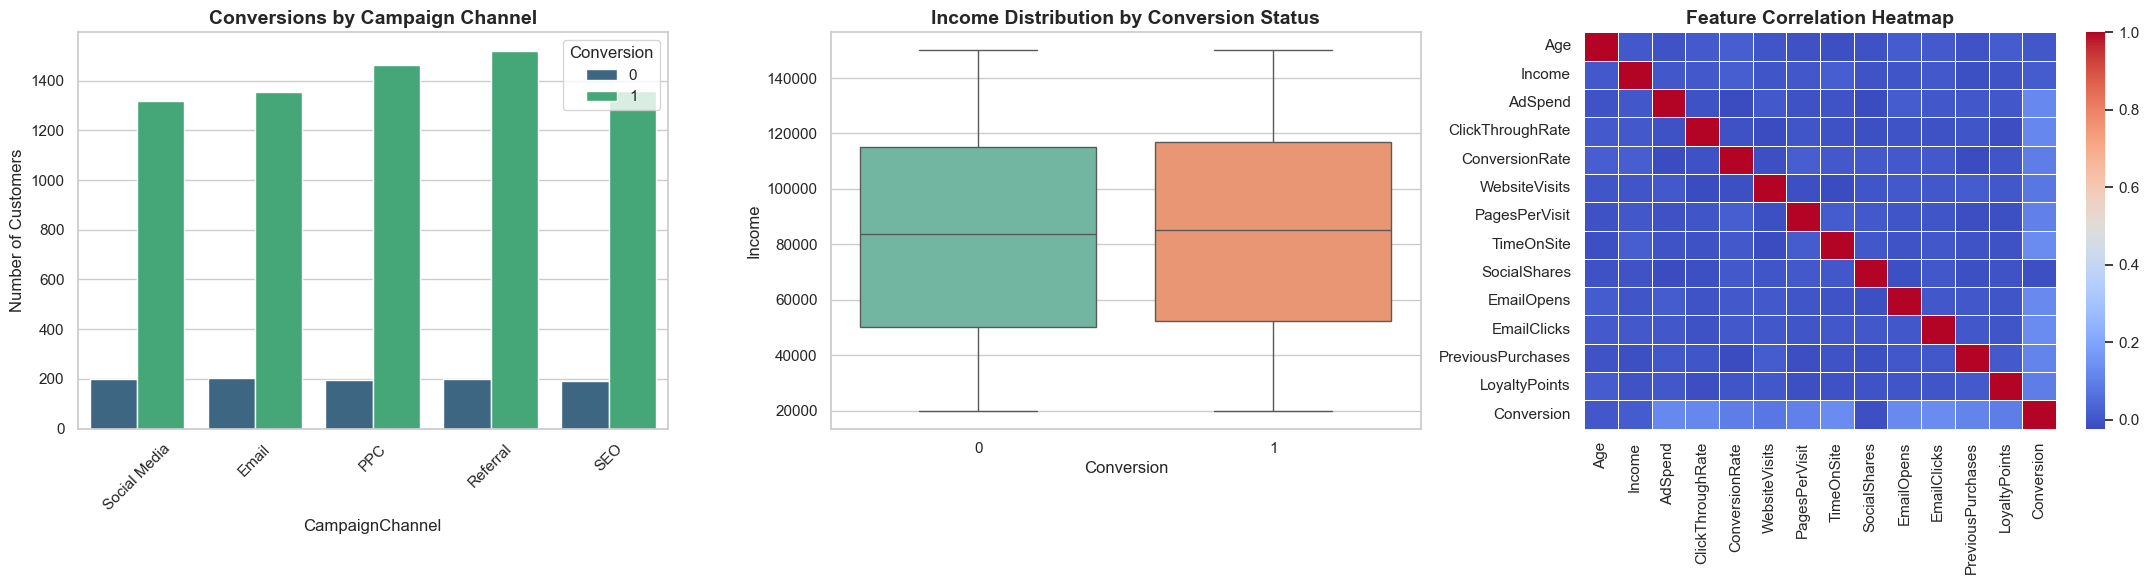

In [2]:
# ==========================================
# PHASE 1B: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# reload here so this cell also works on its own
file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")
df = pd.read_csv(file_path)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) conversions per channel - where do conversions actually come from?
sns.countplot(data=df, x='CampaignChannel', hue='Conversion', ax=axes[0], palette='viridis')
axes[0].set_title('Conversions by Campaign Channel', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

# 2) does income separate converters from non-converters?
sns.boxplot(data=df, x='Conversion', y='Income', ax=axes[1], palette='Set2')
axes[1].set_title('Income Distribution by Conversion Status', fontsize=14, fontweight='bold')

# 3) correlation heatmap - checking for redundant features before modelling
# (CustomerID is just an ID, so it's excluded)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop('CustomerID', axis=1)
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=axes[2], linewidths=0.5)
axes[2].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Engineering

Drop the ID and the two masked vendor columns, one-hot encode the categoricals (gender, channel, campaign type) and standardise the numeric features so nothing dominates just because of its scale.

In [3]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING
# ==========================================
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")
df = pd.read_csv(file_path)

# CustomerID is just an identifier; the two vendor columns are masked ("IsConfid")
# and carry no signal, so all three go
columns_to_drop = ['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool']
df_cleaned = df.drop(columns=columns_to_drop)

X = df_cleaned.drop('Conversion', axis=1)
y = df_cleaned['Conversion']

# one-hot encode the text columns; drop_first avoids the dummy variable trap
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# scale the numeric columns so Income doesn't dominate smaller features like Age
numeric_columns = X_encoded.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

X_scaled = X_encoded.copy()
X_scaled[numeric_columns] = scaler.fit_transform(X_encoded[numeric_columns])

print("Feature engineering done.")
print(f"Original feature shape (before encoding): {X.shape}")
print(f"Engineered feature shape (after encoding): {X_scaled.shape}")
print("\n--- First 3 rows of engineered data ---")
print(X_scaled.head(3))

Feature engineering done.
Original feature shape (before encoding): (8000, 16)
Engineered feature shape (after encoding): (8000, 21)

--- First 3 rows of engineered data ---
        Age    Income   AdSpend  ClickThroughRate  ConversionRate  \
0  0.830400  1.390381  0.527484         -1.320328       -0.298084   
1  1.702775 -1.141736 -0.388418          0.010671        1.427538   
2  0.159343  0.100905 -1.217296          1.460225       -0.509632   

   WebsiteVisits  PagesPerVisit  TimeOnSite  SocialShares  EmailOpens  ...  \
0      -1.729507      -1.208303   -0.078268     -1.065759   -0.608829  ...   
1       1.205221      -1.009576   -0.561778     -1.550199   -1.309262  ...   
2      -1.589758       1.025746    1.435016     -1.723213    0.266712  ...   

   PreviousPurchases  LoyaltyPoints  Gender_Male  CampaignChannel_PPC  \
0          -0.168115      -1.260823        False                False   
1          -0.860656       0.677701         True                False   
2           1.216

## Model Selection & Training

Four classifiers on the same stratified 80/20 split: logistic regression as the baseline, then a decision tree, random forest and gradient boosting. Balanced class weights where the algorithm supports them, so the 13% non-converters don't get ignored.

In [4]:
# ==========================================
# PHASE 3: MODEL SELECTION & TRAINING
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 80/20 split; stratify keeps the 87/13 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape:  {X_test.shape}\n")

# four candidate classifiers - linear baseline, a single tree, and two ensembles
# class_weight='balanced' where supported, so the minority class (non-converters)
# isn't ignored
candidate_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

print("Training models...")
print("--- Initial performance check (F1) ---")
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name:<20} F1: {f1_score(y_test, y_pred):.4f}")

print("\nAll 4 models trained.")

# keep direct references - later cells use these
log_reg = candidate_models["Logistic Regression"]
rf_model = candidate_models["Random Forest"]
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

Training data shape: (6400, 21)
Testing data shape:  (1600, 21)

Training models...
--- Initial performance check (F1) ---
Logistic Regression  F1: 0.9412
Decision Tree        F1: 0.9049


Random Forest        F1: 0.9370


Gradient Boosting    F1: 0.9508

All 4 models trained.


## Evaluation — Confusion Matrix

With an 87/13 imbalance the F1 scores above look great almost no matter what, so the confusion matrix and per-class report tell the real story. Focusing on logistic regression here — it ends up as the champion model (the honest 4-model comparison comes in phases 9–12).

Generating confusion matrix...


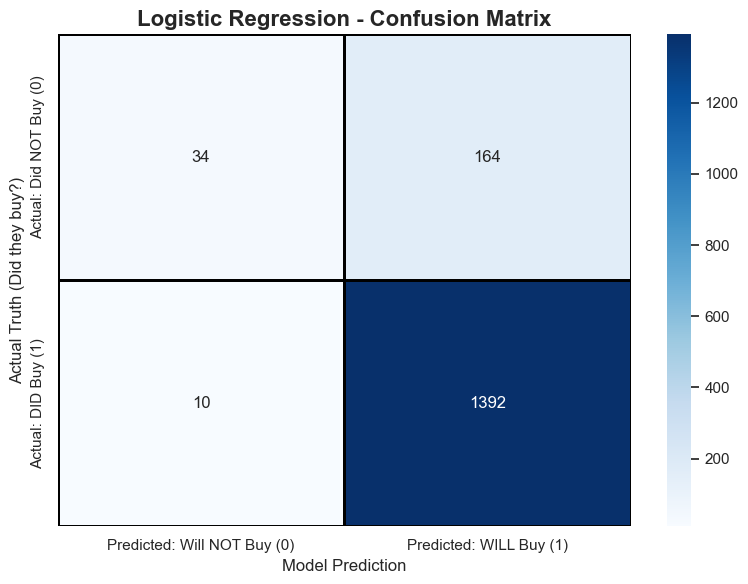


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.17      0.28       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.83      0.58      0.61      1600
weighted avg       0.88      0.89      0.86      1600



In [5]:
# ==========================================
# PHASE 4: PERFORMANCE EVALUATION (CONFUSION MATRIX)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# closer look at logistic regression - it ends up as the champion model
# (the full 4-model comparison with honest scoring is in phases 9-12)
print("Generating confusion matrix...")

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black')

plt.title('Logistic Regression - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Truth (Did they buy?)', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)

# readable labels instead of 0/1
plt.xticks([0.5, 1.5], ['Predicted: Will NOT Buy (0)', 'Predicted: WILL Buy (1)'])
plt.yticks([0.5, 1.5], ['Actual: Did NOT Buy (0)', 'Actual: DID Buy (1)'], va='center')

plt.tight_layout()
plt.show()

# per-class precision/recall/F1 - accuracy alone is misleading at 87/13
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_log))

## Probability Scoring & Export

Score all 8,000 customers with a conversion probability, then tag each prediction with what it means for the ad budget (spend saved, spend wasted, successful target, missed opportunity). This file feeds the dashboard.

In [6]:
# ==========================================
# PHASE 5: PROBABILITY SCORING & EXPORT
# ==========================================
import pandas as pd
import numpy as np

print("Scoring the full customer base...")

# hard predictions plus probability of converting (as a percentage)
all_predictions = log_reg.predict(X_scaled)
probabilities = log_reg.predict_proba(X_scaled)[:, 1] * 100

df_dashboard = df_cleaned.copy()
df_dashboard['AI_Predicted_Conversion'] = all_predictions
df_dashboard['Conversion_Probability_%'] = np.round(probabilities, 2)

# label each customer by what the prediction means for ad spend
def calculate_roas_impact(row):
    if row['Conversion'] == 0 and row['AI_Predicted_Conversion'] == 0:
        return "Ad Spend Saved (True Negative)"
    elif row['Conversion'] == 0 and row['AI_Predicted_Conversion'] == 1:
        return "Ad Spend Wasted (False Positive)"
    elif row['Conversion'] == 1 and row['AI_Predicted_Conversion'] == 1:
        return "Successful Target (True Positive)"
    else:
        return "Missed Opportunity (False Negative)"

df_dashboard['ROAS_Impact'] = df_dashboard.apply(calculate_roas_impact, axis=1)

export_path = "Sellintelligence_Dashboard_Data.csv"
df_dashboard.to_csv(export_path, index=False)

print(f"Done - probability scores added and exported to {export_path}")

Scoring the full customer base...


Done - probability scores added and exported to Sellintelligence_Dashboard_Data.csv


## Business Impact Charts

Two views for stakeholders: the ROAS impact breakdown, and the top drivers of conversion pulled from the model coefficients. Short version — engagement behaviour beats demographics.

Generating business impact and feature importance charts...


C:\Users\Rimi\AppData\Local\Temp\ipykernel_20912\578352300.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=roas_counts.values, y=roas_counts.index, palette=colors)


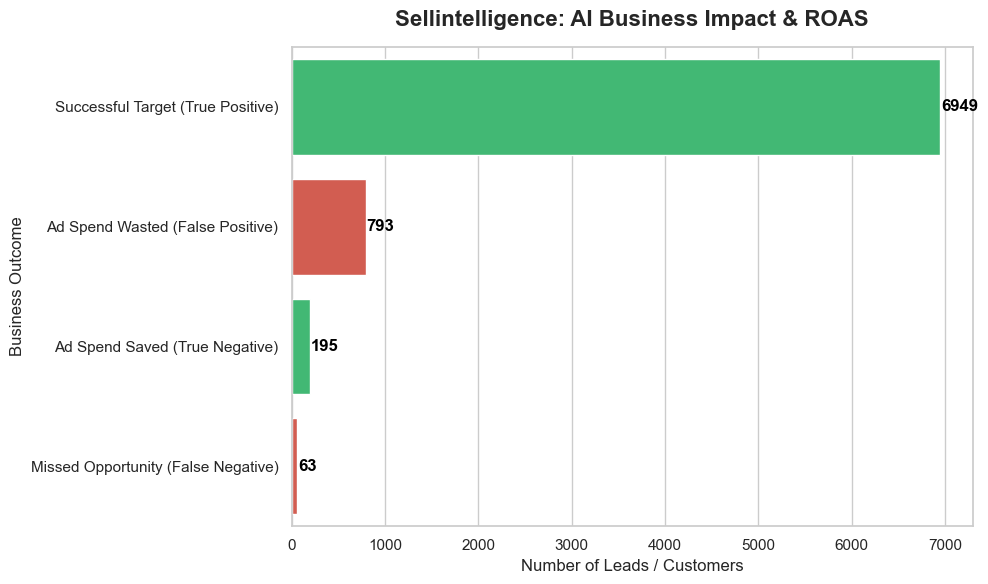

C:\Users\Rimi\AppData\Local\Temp\ipykernel_20912\578352300.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette=feat_colors)


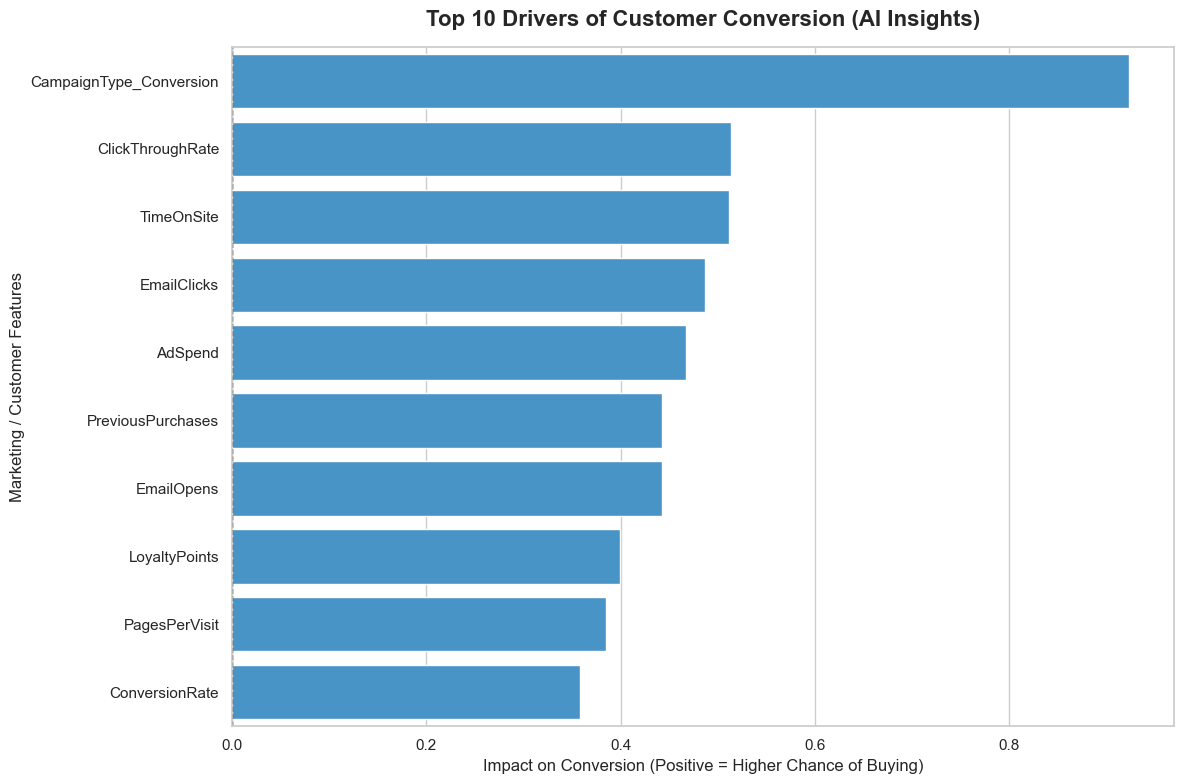

Phase 6 charts generated.


In [7]:
# ==========================================
# PHASE 6: DATA VISUALIZATION & BUSINESS INSIGHTS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Generating business impact and feature importance charts...")

# ---- 1) ROAS impact summary ----
plt.figure(figsize=(10, 6))

roas_counts = df_dashboard['ROAS_Impact'].value_counts()

# green for outcomes that make/save money, red for outcomes that cost money
colors = ['#2ecc71' if 'Saved' in label or 'Successful' in label else '#e74c3c' for label in roas_counts.index]

sns.barplot(x=roas_counts.values, y=roas_counts.index, palette=colors)

plt.title('Sellintelligence: AI Business Impact & ROAS', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Leads / Customers', fontsize=12)
plt.ylabel('Business Outcome', fontsize=12)

# counts at the end of each bar
for index, value in enumerate(roas_counts.values):
    plt.text(value + 10, index, str(value), color='black', va="center", fontweight='bold')

plt.tight_layout()
plt.show()

# ---- 2) what actually drives conversions? ----
plt.figure(figsize=(12, 8))

# logistic regression coefficients double as feature importances
importances = log_reg.coef_[0]

# names must come from the encoded dataframe the model was trained on,
# otherwise the labels won't line up with the coefficients
try:
    features = X_encoded.columns
except NameError:
    print("X_encoded not found - falling back to X.columns")
    features = X.columns

if len(features) != len(importances):
    print(f"Length mismatch: model has {len(importances)} features but got {len(features)} names.")
    print("Make sure 'features' holds the column names of the exact data used for training.")
else:
    feature_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    })

    # rank by absolute value so strong negative drivers also make the top 10
    feature_df['Abs_Importance'] = feature_df['Importance'].abs()
    feature_df = feature_df.sort_values(by='Abs_Importance', ascending=False).head(10)

    # blue pushes towards conversion, orange pushes away
    feat_colors = ['#3498db' if val > 0 else '#f39c12' for val in feature_df['Importance']]

    sns.barplot(x='Importance', y='Feature', data=feature_df, palette=feat_colors)

    plt.title('Top 10 Drivers of Customer Conversion (AI Insights)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Impact on Conversion (Positive = Higher Chance of Buying)', fontsize=12)
    plt.ylabel('Marketing / Customer Features', fontsize=12)

    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

print("Phase 6 charts generated.")

## Lead Scoring & ROI Simulation

Bucket customers into hot / warm / cold leads from their conversion probability, then put a dollar figure on the model: at ~$50 per ad, how much do we save by not advertising to the cold leads?

Generating lead scores and the ROI estimate...


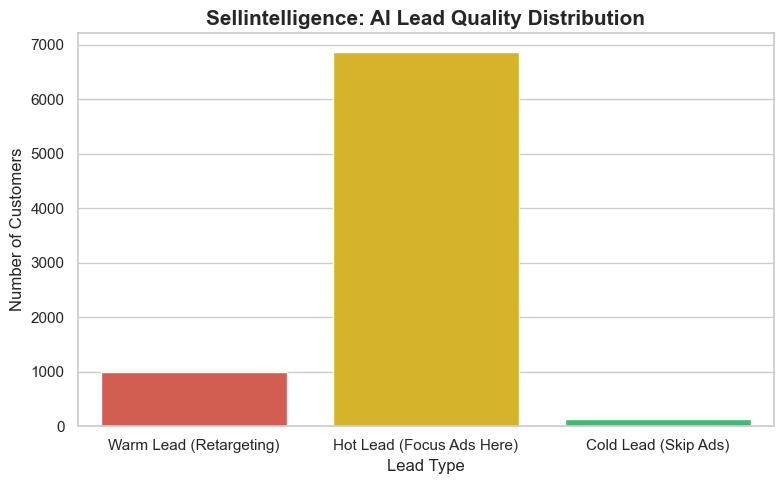


SELLINTELLIGENCE FINANCIAL IMPACT (SIMULATED)
Total customers in database: 8000
Cold leads identified (ads skipped): 195
--------------------------------------------------
Estimated cost per ad: $50
Total ad-spend saved: $9,750.00

Merging predictions with the raw marketing data...
Merged and exported - ready for Power BI.


In [8]:
# ==========================================
# PHASE 7: LEAD SCORING & ROI SIMULATION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating lead scores and the ROI estimate...")

# ---- 1) lead scoring from conversion probability ----
probabilities = log_reg.predict_proba(X_scaled)[:, 1]
df_dashboard['Conversion_Probability_%'] = (probabilities * 100).round(2)

# three tiers the marketing team can act on directly
def lead_category(prob):
    if prob >= 75:
        return "Hot Lead (Focus Ads Here)"
    elif prob >= 40:
        return "Warm Lead (Retargeting)"
    else:
        return "Cold Lead (Skip Ads)"

df_dashboard['Lead_Quality'] = df_dashboard['Conversion_Probability_%'].apply(lead_category)

plt.figure(figsize=(8, 5))
# hue= plus legend=False avoids the seaborn deprecation warning
sns.countplot(data=df_dashboard, x='Lead_Quality', hue='Lead_Quality', palette=['#e74c3c', '#f1c40f', '#2ecc71'], legend=False)
plt.title('Sellintelligence: AI Lead Quality Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Lead Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()

# ---- 2) how much ad spend does skipping the cold leads save? ----
# working assumption: about $50 to serve ads to one customer over a campaign
COST_PER_AD = 50

# true negatives = customers the model correctly said would not convert
true_negatives = df_dashboard[df_dashboard['ROAS_Impact'] == "Ad Spend Saved (True Negative)"].shape[0]
dollars_saved = true_negatives * COST_PER_AD

print("\n" + "="*50)
print("SELLINTELLIGENCE FINANCIAL IMPACT (SIMULATED)")
print("="*50)
print(f"Total customers in database: {len(df_dashboard)}")
print(f"Cold leads identified (ads skipped): {true_negatives}")
print("-" * 50)
print(f"Estimated cost per ad: ${COST_PER_AD}")
print(f"Total ad-spend saved: ${dollars_saved:,.2f}")
print("="*50)

# ---- 3) add the campaign columns back for the BI dashboard ----
print("\nMerging predictions with the raw marketing data...")

df_raw = pd.read_csv("Sellintelligence_Dashboard_Data.csv")

# row order matches the original dataframe, so direct assignment is safe
df_dashboard['CampaignChannel'] = df_raw['CampaignChannel']
df_dashboard['CampaignType'] = df_raw['CampaignType']

df_dashboard.to_csv("Sellintelligence_Final_Master_Data.csv", index=False)

print("Merged and exported - ready for Power BI.")

## Final Evaluation & Model Serialisation

One last look at the classification report, then the trained model gets saved with joblib so it can be loaded in production without retraining.

In [9]:
# ==========================================
# PHASE 8: FINAL EVALUATION & SAVING THE MODEL
# ==========================================
from sklearn.metrics import classification_report
import joblib
import os

print("1. Final model evaluation (class 0 recall is the number to watch)...")
print("-" * 60)

y_pred_final = log_reg.predict(X_test)

report = classification_report(y_test, y_pred_final)
print(report)

print("-" * 60)
print("\n2. Saving the trained model to disk...")
print("-" * 60)

model_filename = 'Sellintelligence_Final_Model.pkl'
joblib.dump(log_reg, model_filename)

current_directory = os.getcwd()
print(f"Model saved as '{model_filename}'")
print(f"Location: {current_directory}")

1. Final model evaluation (class 0 recall is the number to watch)...
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.17      0.28       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.83      0.58      0.61      1600
weighted avg       0.88      0.89      0.86      1600

------------------------------------------------------------

2. Saving the trained model to disk...
------------------------------------------------------------
Model saved as 'Sellintelligence_Final_Model.pkl'
Location: D:\DSDA PROJECTS\Sellintelligence


## Leak-Free Rebuild + Honest Scoring

Being honest about a flaw in the first pass: the scaler in phase 2 was fit on the full dataset *before* splitting, which leaks a bit of test information into training. This rebuild puts all preprocessing inside sklearn Pipelines (fit per CV fold) and re-scores all four models under identical conditions, plus out-of-fold probabilities for the whole customer base.

In [10]:
# ==========================================
# PHASE 9: LEAK-FREE REBUILD + HONEST SCORING
# ==========================================
# The phase 2 scaler was fit on the full dataset before splitting, which leaks a
# little test information into training. Rebuilding with sklearn Pipelines here so
# scaling/encoding happen inside each CV fold, then re-scoring all four models.
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")
df = pd.read_csv(file_path)

TARGET = "Conversion"
drop_cols = ["CustomerID", "AdvertisingPlatform", "AdvertisingTool"]
X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# preprocessing lives inside the pipeline, so each fold fits its own scaler/encoder
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])

# same four classifiers as phase 3, now under identical leak-free conditions
models = {
    "Logistic Regression": Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))]),
    "Decision Tree":       Pipeline([("pre", pre), ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))]),
    "Random Forest":       Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))]),
    "Gradient Boosting":   Pipeline([("pre", pre), ("clf", GradientBoostingClassifier(random_state=42))]),
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# out-of-fold probabilities: every customer gets scored by a model that never saw them
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = {}
for name, pipe in models.items():
    oof_proba[name] = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    pipe.fit(X_train, y_train)  # fit on the train split for test-set evaluation

print("Phase 9 complete: 4 models trained, out-of-fold probabilities computed (no leakage).")


Phase 9 complete: 4 models trained, out-of-fold probabilities computed (no leakage).


## Churn Analysis

There are no subscription or renewal dates in this dataset, so churn is defined as a proxy and stated openly: an **existing customer** (has previous purchases) who **didn't convert** in this campaign counts as lapsed. Churn risk = 1 − P(conversion). A few extra readable columns get added here purely so the Power BI page works without DAX measures.

In [11]:
# ==========================================
# PHASE 10: CHURN-PROXY CURATION
# ==========================================
# There are no subscription/renewal dates in this dataset, so churn is a proxy
# (stated openly in the report):
#   existing customer = PreviousPurchases > 0
#   churned (lapsed)  = existing customer who did NOT convert in this campaign
#   churn risk score  = 1 - P(conversion), from the out-of-fold probabilities
CHAMPION = "Logistic Regression"

churn = df.copy()
churn["Is_Existing_Customer"] = (churn["PreviousPurchases"] > 0).astype(int)
churn["Churned"] = ((churn["Is_Existing_Customer"] == 1) & (churn[TARGET] == 0)).astype(int)
churn["Churn_Risk_Score_%"] = np.round((1 - oof_proba[CHAMPION]) * 100, 2)

def risk_tier(p):
    if p >= 60: return "High Risk"
    if p >= 30: return "Medium Risk"
    return "Low Risk"
churn["Churn_Risk_Tier"] = churn["Churn_Risk_Score_%"].apply(risk_tier)

# flag customers who are quiet on both email and the website
churn["Low_Engagement"] = ((churn["EmailOpens"] < churn["EmailOpens"].median()) &
                           (churn["WebsiteVisits"] < churn["WebsiteVisits"].median())).astype(int)

# extra columns so Power BI can show churn rates without needing DAX measures:
#   Churned_Pct      - averaging this column gives the churn rate in percent
#   Engagement_Level - readable label instead of 0/1
#   Customer_Status  - readable churned/retained label
#   Age_Band         - pre-binned age groups for consistent visuals
churn["Churned_Pct"] = churn["Churned"] * 100
churn["Engagement_Level"] = np.where(churn["Low_Engagement"] == 1, "Low Engagement", "Engaged")
churn["Customer_Status"] = np.where(churn["Churned"] == 1, "Churned", "Retained")
churn["Age_Band"] = pd.cut(churn["Age"], bins=[17, 25, 35, 45, 55, 70],
                           labels=["18-25", "26-35", "36-45", "46-55", "56-70"]).astype(str)

churn.to_csv("PBI_Churn_Data.csv", index=False)

# churn summary per segment - existing customers only, since churn rate
# makes no sense for prospects who never bought anything
existing = churn[churn["Is_Existing_Customer"] == 1]
seg_frames = []
for seg in ["CampaignChannel", "CampaignType", "Gender", "Churn_Risk_Tier"]:
    g = existing.groupby(seg).agg(
        Customers=("Churned", "size"),
        Churned=("Churned", "sum"),
        Avg_Risk_Score=("Churn_Risk_Score_%", "mean"),
        Avg_LoyaltyPoints=("LoyaltyPoints", "mean"),
        Avg_EmailOpens=("EmailOpens", "mean"),
    ).reset_index().rename(columns={seg: "Segment_Value"})
    g["Segment_Type"] = seg
    g["Churn_Rate_%"] = np.round(g["Churned"] / g["Customers"] * 100, 2)
    seg_frames.append(g)

# same summary by age band
g = existing.groupby("Age_Band", observed=True).agg(
    Customers=("Churned","size"), Churned=("Churned","sum"),
    Avg_Risk_Score=("Churn_Risk_Score_%","mean"),
    Avg_LoyaltyPoints=("LoyaltyPoints","mean"), Avg_EmailOpens=("EmailOpens","mean"),
).reset_index().rename(columns={"Age_Band":"Segment_Value"})
g["Segment_Type"] = "Age_Band"
g["Churn_Rate_%"] = np.round(g["Churned"]/g["Customers"]*100, 2)
seg_frames.append(g)

pd.concat(seg_frames, ignore_index=True).to_csv("PBI_Churn_Segment_Summary.csv", index=False)
print("Phase 10 complete:")
print(f"  Existing customers: {len(existing):,} | Churned (lapsed): {existing['Churned'].sum():,} "
      f"({existing['Churned'].mean()*100:.1f}%)")
print("  Exported: PBI_Churn_Data.csv, PBI_Churn_Segment_Summary.csv")


Phase 10 complete:
  Existing customers: 7,162 | Churned (lapsed): 798 (11.1%)
  Exported: PBI_Churn_Data.csv, PBI_Churn_Segment_Summary.csv


## Power BI Exports — Model Performance

Everything the Model Performance dashboard page needs, as tidy CSVs: overall and per-class metrics, confusion matrices in long format, downsampled ROC points, a small model-dimension table (so one slicer can filter every model table), and gain/lift deciles for the champion.

In [12]:
# ==========================================
# PHASE 11: MODEL PERFORMANCE EXPORT (for Power BI)
# ==========================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix, roc_curve)

metric_rows, cm_rows, roc_rows = [], [], []

for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Overall + per-class metrics (class 0 recall is the money metric on 87/13 imbalance)
    metric_rows.append({"Model": name, "Class": "Overall",
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted")})
    for cls in [0, 1]:
        metric_rows.append({"Model": name, "Class": f"Class {cls}",
            "Accuracy": None, "ROC_AUC": None, "PR_AUC": None,
            "Precision": precision_score(y_test, y_pred, pos_label=cls),
            "Recall": recall_score(y_test, y_pred, pos_label=cls),
            "F1": f1_score(y_test, y_pred, pos_label=cls)})

    # Confusion matrix in long format (best for a Power BI matrix visual)
    cm = confusion_matrix(y_test, y_pred)
    labels = {0: "Not Converted", 1: "Converted"}
    for i in [0, 1]:
        for j in [0, 1]:
            cm_rows.append({"Model": name, "Actual": labels[i], "Predicted": labels[j],
                            "Count": int(cm[i, j])})

    # ROC curve points (downsampled to ~100 pts so PBI stays snappy)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    idx = np.linspace(0, len(fpr) - 1, min(100, len(fpr))).astype(int)
    for f, t in zip(fpr[idx], tpr[idx]):
        roc_rows.append({"Model": name, "FPR": round(float(f), 4), "TPR": round(float(t), 4)})

pd.DataFrame(metric_rows).round(4).to_csv("PBI_Model_Metrics.csv", index=False)
pd.DataFrame(cm_rows).to_csv("PBI_Confusion_Matrix.csv", index=False)
pd.DataFrame(roc_rows).to_csv("PBI_ROC_Curve.csv", index=False)

# Model dimension table -> lets one Power BI slicer filter every model-related table
# (Power BI auto-detects the 1-to-many relationships on Model when this loads)
pd.DataFrame({"Model": list(models.keys())}).to_csv("PBI_Models.csv", index=False)

# Gain/lift deciles from the champion's out-of-fold probabilities
dec = pd.DataFrame({"prob": oof_proba[CHAMPION], "actual": y.values})
dec["Decile"] = pd.qcut(dec["prob"].rank(method="first", ascending=False), 10, labels=range(1, 11))
gain = dec.groupby("Decile", observed=True).agg(Customers=("actual","size"),
                                                Converters=("actual","sum"),
                                                Avg_Predicted_Prob=("prob","mean")).reset_index()
gain["Conversion_Rate_%"] = np.round(gain["Converters"]/gain["Customers"]*100, 2)
gain["Cumulative_Gain_%"] = np.round(gain["Converters"].cumsum()/gain["Converters"].sum()*100, 2)
gain.round(4).to_csv("PBI_Gain_Deciles.csv", index=False)

print("Phase 11 complete. Exported: PBI_Model_Metrics.csv, PBI_Confusion_Matrix.csv, "
      "PBI_ROC_Curve.csv, PBI_Models.csv, PBI_Gain_Deciles.csv")
print(pd.DataFrame(metric_rows).round(3).to_string(index=False))


Phase 11 complete. Exported: PBI_Model_Metrics.csv, PBI_Confusion_Matrix.csv, PBI_ROC_Curve.csv, PBI_Models.csv, PBI_Gain_Deciles.csv
              Model   Class  Accuracy  ROC_AUC  PR_AUC  Precision  Recall    F1
Logistic Regression Overall     0.754    0.782   0.945      0.872   0.754 0.792
Logistic Regression Class 0       NaN      NaN     NaN      0.299   0.732 0.425
Logistic Regression Class 1       NaN      NaN     NaN      0.952   0.757 0.844
      Decision Tree Overall     0.833    0.625   0.904      0.836   0.833 0.835
      Decision Tree Class 0       NaN      NaN     NaN      0.333   0.348 0.341
      Decision Tree Class 1       NaN      NaN     NaN      0.907   0.902 0.904
      Random Forest Overall     0.883    0.810   0.949      0.876   0.883 0.837
      Random Forest Class 0       NaN      NaN     NaN      0.824   0.071 0.130
      Random Forest Class 1       NaN      NaN     NaN      0.884   0.998 0.937
  Gradient Boosting Overall     0.910    0.817   0.950      0.905 

## Precision-Recall Curves

The most honest lens for this dataset: a no-skill model sits at 0.88 precision no matter what, so any real skill shows up as lift above that line. Gradient boosting wins on PR-AUC, but logistic regression stays the champion — it catches far more non-converters, which is where the ad-budget savings actually come from.

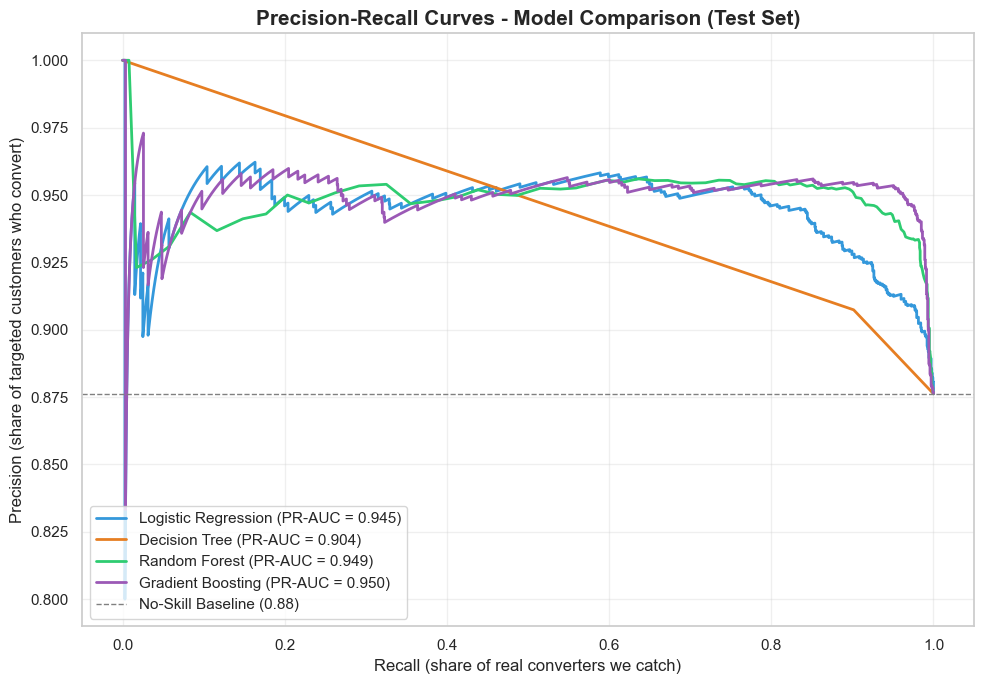

              Model  PR_AUC
  Gradient Boosting  0.9504
      Random Forest  0.9485
Logistic Regression  0.9450
      Decision Tree  0.9043

Exported: PBI_PR_Curve.csv
Phase 12 complete: precision-recall evaluation finished for all 4 classifiers.


In [13]:
# ==========================================
# PHASE 12: PRECISION-RECALL CURVES (ALL 4 MODELS)
# ==========================================
# With an 87/13 imbalance the PR curve is more honest than accuracy - it shows the
# trade-off between catching real converters (recall) and not wasting ad spend on
# the wrong customers (precision) at every threshold.
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))
colors = {"Logistic Regression": "#3498db", "Decision Tree": "#e67e22",
          "Random Forest": "#2ecc71", "Gradient Boosting": "#9b59b6"}

pr_summary, pr_rows = [], []
for name, pipe in models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    pr_summary.append({"Model": name, "PR_AUC": round(pr_auc, 4)})
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})",
             color=colors[name], linewidth=2)

    # downsampled PR points for the Power BI model performance page
    idx = np.linspace(0, len(recall) - 1, min(100, len(recall))).astype(int)
    for rc, pc in zip(recall[idx], precision[idx]):
        pr_rows.append({"Model": name, "Recall": round(float(rc), 4),
                        "Precision": round(float(pc), 4)})

pd.DataFrame(pr_rows).to_csv("PBI_PR_Curve.csv", index=False)

# a no-skill classifier sits at precision = the positive class rate (~0.88)
baseline = y_test.mean()
plt.axhline(y=baseline, color="grey", linestyle="--", linewidth=1,
            label=f"No-Skill Baseline ({baseline:.2f})")

plt.title("Precision-Recall Curves - Model Comparison (Test Set)", fontsize=15, fontweight="bold")
plt.xlabel("Recall (share of real converters we catch)", fontsize=12)
plt.ylabel("Precision (share of targeted customers who convert)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(pd.DataFrame(pr_summary).sort_values("PR_AUC", ascending=False).to_string(index=False))
print("\nExported: PBI_PR_Curve.csv")
print("Phase 12 complete: precision-recall evaluation finished for all 4 classifiers.")